# 4장 실습 ③ — 증강은 도메인이 정합니다

**TensorFlow 판**

§4.5의 표에 이렇게 적혀 있습니다.

| 데이터 | 좌우 반전 | 이동 |
|---|:--:|:--:|
| 손글씨 숫자 | **✗** (2와 5가 섞임) | ○ |

**정말 그런지 봅니다.** 같은 증강을 하나는 알맞게, 하나는 잘못 걸고
학습시켜 견줍니다.

> 데이터를 **네 배로 늘렸는데 성능이 떨어지는 것**을 보시게 됩니다.

## 4.0 준비

In [1]:
try:
    import dlbook
except ImportError:
    !pip install -q "dlbook @ git+https://github.com/dhrim/deep-learning-in-one-semester.git"
    import dlbook

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import dlbook
from dlbook import data, metrics, plot

dlbook.set_seed(42)
plot.use_korean()
print(dlbook.versions())

{'python': '3.12.3', 'numpy': '2.1.3', 'keras': '3.15.1', 'tensorflow': '2.21.0', 'torch': '-', 'keras_backend': 'tensorflow'}


## 4.1 데이터를 일부러 적게 씁니다

구분            개수  입력 shape
train        500  (28, 28, 1)
val          500  (28, 28, 1)
test        2000  (28, 28, 1)


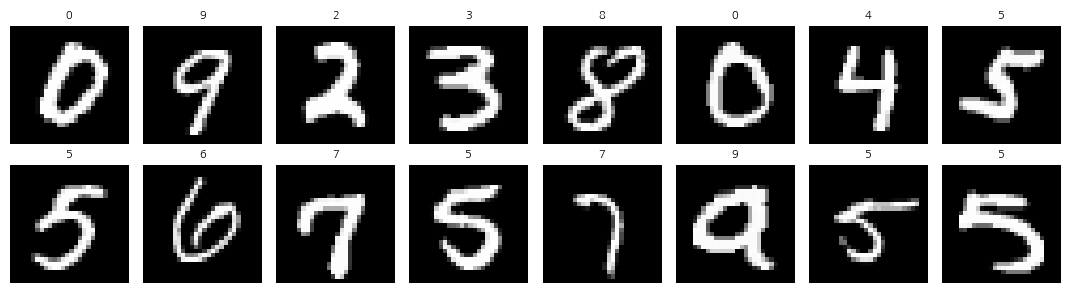

In [3]:
# §4.1의 "영상은 300~500장이면 유의미하다"를 확인하려면
# **일부러 적게** 써야 합니다. 5만 장을 쓰면 증강해도 티가 안 납니다.
N_TRAIN = 500
full = data.mnist()
s = data.Split(full.x_train[:N_TRAIN], full.y_train[:N_TRAIN],
               full.x_val[:500], full.y_val[:500],
               full.x_test[:2000], full.y_test[:2000])
print(s.summary())
plot.image_grid(s.x_train, s.y_train, n=16, cols=8)
plt.show()

## 4.2 증강 — numpy 열 줄이면 됩니다

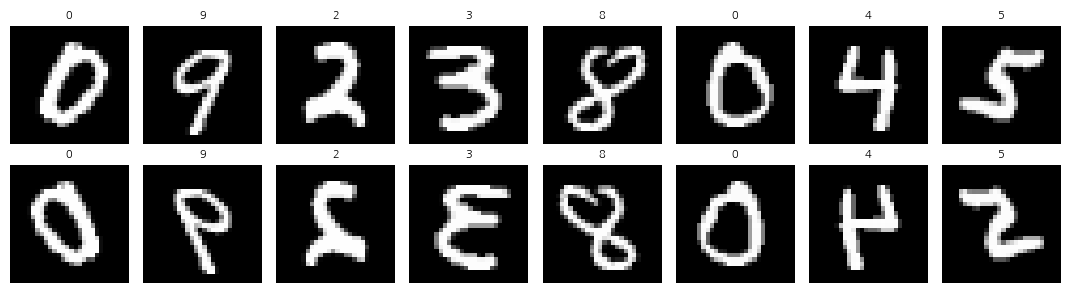

★ 윗줄이 원본, 아랫줄이 좌우 반전입니다.
  뒤집힌 2는 2가 아닙니다. 그런데 정답표에는 여전히 2라고 적혀 있습니다.


In [4]:
def shift(img, dy, dx):
    """이미지를 상하좌우로 옮긴다. 빈 자리는 0."""
    out = np.zeros_like(img)
    h, w = img.shape[:2]
    ys, ye = max(0, dy), min(h, h + dy)
    xs, xe = max(0, dx), min(w, w + dx)
    out[ys:ye, xs:xe] = img[ys - dy:ye - dy, xs - dx:xe - dx]
    return out


def augment(x, y, times, mode, seed=42):
    """원본 + 변형본 times벌. **학습 데이터에만 씁니다.**

    검증·시험은 성능을 재는 자리이므로 원본 그대로여야 합니다 (§4.5).
    """
    rng = np.random.default_rng(seed)
    xs, ys = [x], [y]
    for _ in range(times):
        batch = np.empty_like(x)
        for i, im in enumerate(x):
            if mode == "shift":
                batch[i] = shift(im, rng.integers(-2, 3), rng.integers(-2, 3))
            else:                                   # "flip" — 좌우 반전
                batch[i] = im[:, ::-1]
        xs.append(batch); ys.append(y)
    return np.concatenate(xs), np.concatenate(ys)


x_flip, _ = augment(s.x_train[:8], s.y_train[:8], 1, "flip")
plot.image_grid(x_flip, np.concatenate([s.y_train[:8]] * 2), n=16, cols=8)
plt.show()
print("★ 윗줄이 원본, 아랫줄이 좌우 반전입니다.")
print("  뒤집힌 2는 2가 아닙니다. 그런데 정답표에는 여전히 2라고 적혀 있습니다.")

## 4.3 학습 함수 — 여기만 판마다 다릅니다

In [5]:
import tensorflow as tf

L_ = tf.keras.layers

def train(xt, yt, s, epochs=25):
    """작은 CNN. **이 함수만 판마다 다릅니다.**"""
    dlbook.set_seed(42)
    m = tf.keras.Sequential([
        L_.Input(shape=(28, 28, 1)),
        L_.Conv2D(16, 3, activation="relu"), L_.MaxPooling2D(2),
        L_.Conv2D(32, 3, activation="relu"), L_.MaxPooling2D(2),
        L_.Flatten(), L_.Dense(64, activation="relu"),
        L_.Dense(10, activation="softmax")])
    m.compile(optimizer=tf.keras.optimizers.Adam(0.001),
              loss="sparse_categorical_crossentropy")
    m.fit(xt, yt, epochs=dlbook.smoke.epochs(epochs), batch_size=64, verbose=0)
    pred = m.predict(s.x_test, verbose=0, batch_size=512).argmax(1)
    return metrics.accuracy(s.y_test, pred)

## 4.4 켜고, 끄고, 잘못 켜고

In [6]:
CASES = [("증강 없음", None), ("이동 ±2픽셀", "shift"), ("좌우 반전", "flip")]
TIMES = 3

result = {}
print(f"{'':<16}{'학습 장수':>10}{'시험 정확도':>14}")
print("-" * 40)
for name, mode in CASES:
    if mode is None:
        xt, yt = s.x_train, s.y_train
    else:
        xt, yt = augment(s.x_train, s.y_train, TIMES, mode)
    a = train(xt, yt, s)
    result[name] = a
    print(f"{name:<16}{len(xt):>10,}{a:>14.3f}", flush=True)
    dlbook.record(f"ch04_aug_{mode or 'none'}", a)

print()
print(f"★ 이동은 **+{result['이동 ±2픽셀'] - result['증강 없음']:.3f}**. "
      f"장수만 늘린 것이 아니라 실제로 도움이 됐습니다.")
print(f"★ 좌우 반전은 **{result['좌우 반전'] - result['증강 없음']:+.3f}**. "
      f"**데이터를 네 배로 늘렸는데 더 나빠졌습니다.**")
print("  현실에 없는 데이터를 학습시킨 값입니다.")

                     학습 장수        시험 정확도
----------------------------------------


증강 없음                  500         0.881


ch04_aug_none = 0.8810


이동 ±2픽셀              2,000         0.917


ch04_aug_shift = 0.9170


좌우 반전                2,000         0.829


ch04_aug_flip = 0.8290

★ 이동은 **+0.036**. 장수만 늘린 것이 아니라 실제로 도움이 됐습니다.
★ 좌우 반전은 **-0.052**. **데이터를 네 배로 늘렸는데 더 나빠졌습니다.**
  현실에 없는 데이터를 학습시킨 값입니다.


## 정리

| | 학습 장수 | 시험 정확도 |
|---|--:|:--:|
| 증강 없음 | 500 | 0.881 |
| **이동 ±2픽셀** | 2,000 | **0.917** |
| **좌우 반전** | 2,000 | **0.829** |

- **알맞은 증강은 이깁니다.** 500장으로 0.881이던 것이 2,000장으로
  0.917이 됐습니다(+0.036). 사진을 더 찍지 않고 얻은 것입니다.
- **잘못된 증강은 데이터를 네 배로 늘리고도 집니다.** 0.881 → 0.829
  (-0.052). 뒤집힌 2를 2라고 가르쳤기 때문입니다.
  **현실에 없는 데이터입니다.**
- 그래서 §4.5의 문장이 그대로 성립합니다 —
  **"이렇게 변형해도 정답이 그대로인가"를 사람이 판단해서 켜는 것입니다.
  기계가 정해 주지 않습니다.**
- 위성 영상이었다면 좌우 반전도 상하 반전도 켰을 것입니다. 같은 증강이
  **데이터가 무엇이냐에 따라** 약이 되기도 독이 되기도 합니다.

### 연습

1. `TIMES` 를 3에서 7로 올리면(원본의 8배) 얼마나 더 좋아집니까.
   계속 좋아집니까, 어디서 멈춥니까.
2. 이동 폭을 ±2에서 **±8픽셀**로 키우십시오. 도움이 됩니까 방해가 됩니까.
   왜 그렇습니까.
3. `N_TRAIN` 을 500에서 5,000으로 올리고 다시 하십시오.
   **증강의 이득이 커집니까 작아집니까.** 그 이유를 §4.1과 엮어 설명하십시오.
4. 좌우 반전이 **도움이 되는** 데이터를 하나 고르고, 왜 그런지 쓰십시오.
5. 8장을 미리 보십시오. 이동 증강이 CNN에 주는 이득과 DNN에 주는 이득 중
   어느 쪽이 클 것 같습니까. 돌려서 확인하십시오.